# Function 1 — Week 9: Hurdle Model with log Transform (No Penalties)

**Iteration**: Week 9 (19 observations: 10 initial + 9 weekly submissions)  
**Strategy**: Two-stage hurdle model surrogate with exploitation-focused weighted UCB acquisition (no penalties).  
**Key changes from Week 8**: (1) Stage 2 RF regressor now trains on `log(y)` instead of `log1p(y)` for positive outputs. (2) Local penalization and interior penalty removed from acquisition function. (3) KAPPA reduced from 3.0 to 0.5 — exploitation-focused, because the log transform gives the surrogate meaningful signal to exploit and only 4 submissions remain in budget.  
**Goal**: Propose next sample point for Function 1 (2D radiation source detection).

**Enhancements in Week 9**:
- **log transform**: Stage 2 uses `np.log(y_pos)` instead of `np.log1p(y_pos)` — produces meaningful spread in target values (~-565 to ~-35) for F1's tiny positive outputs
- **Exploitation focus**: KAPPA reduced from 3.0 to 0.5 — the improved surrogate scaling justifies trusting the surrogate's predicted best regions; only 4 budget submissions remain
- **Simplified acquisition**: Raw weighted UCB with no local penalization or interior penalty
- **Three-colour visualisation**: Initial samples (blue), weekly submissions (orange), proposed next point (green star)
- **Performance evaluation**: Convergence metrics, exploration spread analysis, LOO surrogate error, and strategy interpretation

### Strategy Summary

F1 has returned **zero improvement** across multiple consecutive submissions. However, the switch from `log1p` to `log` now gives the surrogate meaningful signal (R² ≈ 0.90 on log-scale targets). With the surrogate now able to differentiate observations, the strategy shifts to **exploitation** (κ = 0.5) to sample near predicted optima:

1. **Hurdle Model (Surrogate)**: Two-stage approach handling zero-inflated outputs:
   - *Stage 1 — Classifier*: `CalibratedClassifierCV(LogisticRegression)` estimates P(y > 0)
   - *Stage 2 — Regressor*: `RandomForestRegressor` on log(y) for positive outputs (or fallback to pure exploration if < 3 positive samples)

2. **Weighted UCB Acquisition**: $a(x) = p(x) \cdot \mu(x) + \kappa \cdot p(x) \cdot \sigma_{\text{RF}}(x)$ with κ = 0.5 (exploitation-focused)

This notebook is **self-contained** per constitution principle III.

In [1]:
# --- Imports ---
import numpy as np
import matplotlib.pyplot as plt
import warnings
from scipy.spatial.distance import pdist, squareform
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestRegressor

print("All imports successful.")

All imports successful.


## Hyperparameters

All tunable parameters for the Week 9 hurdle model and acquisition function. Key changes from Week 8: log1p → log transform, local penalization and interior penalty removed, KAPPA reduced from 3.0 to 0.5 for exploitation.

| Parameter | Value | Rationale |
|-----------|-------|----------|
| **C_STAGE1** | 1.0 | Default L2 regularisation for LogisticRegression; balanced for 19-sample dataset. |
| **N_ESTIMATORS** | 100 | Standard RF ensemble size; provides stable uncertainty from per-tree prediction std. |
| **MAX_DEPTH** | 3 | Constrains tree depth to prevent overfitting with few positive-output samples. |
| **KAPPA** | 0.5 | Exploitation-focused UCB weight. Log transform gives the surrogate meaningful signal to exploit; only 4 submissions remain in budget. |
| **N_CANDIDATES** | 20000 | Dense uniform coverage of 2D space for acquisition maximisation. |
| **GRID_RES** | 50 | 50×50 = 2500 grid points for visualisation. |
| **MIN_POSITIVE** | 3 | Minimum positive samples for Stage 2 RF training; below this triggers fallback. |

In [2]:
# --- Data Shape Constants ---
N_INITIAL   = 10          # Initial samples
N_TOTAL     = 19          # Total samples through Week 9 (10 + 9 weekly)
N_DIMS      = 2           # Input dimensionality
N_SUBMISSIONS = N_TOTAL - N_INITIAL  # 9 weekly submissions

# --- Hyperparameter Constants ---
C_STAGE1       = 1.0      # Logistic Regression regularisation strength
N_ESTIMATORS   = 100      # Number of Random Forest trees in Stage 2
MAX_DEPTH      = 3        # Maximum tree depth — constrains overfitting
KAPPA          = 0.5      # UCB exploitation parameter (exploitation-focused)
N_CANDIDATES   = 20_000   # Number of random UCB candidates
GRID_RES       = 50       # Visualization grid resolution (50x50)
MIN_POSITIVE   = 3        # Minimum positive-output samples for Stage 2

# --- Performance Evaluation Constants ---
STALLING_CONSECUTIVE_THRESHOLD = 3    # Trailing no-improvement streak to flag stalling
STALLING_RELATIVE_THRESHOLD    = 0.05 # Relative improvement below this → stalling

print("Week 9 Hyperparameters:")
print(f"  N_INITIAL:     {N_INITIAL}")
print(f"  N_TOTAL:       {N_TOTAL}")
print(f"  N_SUBMISSIONS: {N_SUBMISSIONS}")
print(f"  C_STAGE1:       {C_STAGE1}")
print(f"  N_ESTIMATORS:   {N_ESTIMATORS}")
print(f"  MAX_DEPTH:      {MAX_DEPTH}")
print(f"  KAPPA:          {KAPPA}")
print(f"  N_CANDIDATES:   {N_CANDIDATES}")
print(f"  GRID_RES:       {GRID_RES}")
print(f"  MIN_POSITIVE:   {MIN_POSITIVE}")
print(f"  Stalling threshold (consecutive): {STALLING_CONSECUTIVE_THRESHOLD}")
print(f"  Stalling threshold (relative):    {STALLING_RELATIVE_THRESHOLD}")

Week 9 Hyperparameters:
  N_INITIAL:     10
  N_TOTAL:       19
  N_SUBMISSIONS: 9
  C_STAGE1:       1.0
  N_ESTIMATORS:   100
  MAX_DEPTH:      3
  KAPPA:          0.5
  N_CANDIDATES:   20000
  GRID_RES:       50
  MIN_POSITIVE:   3
  Stalling threshold (consecutive): 3
  Stalling threshold (relative):    0.05


## Step 1: Load and Validate Week 9 Data

Load the updated Week 9 data containing all 19 observations (10 initial + 9 weekly submissions). Validate shapes, ranges, split into initial/submission subsets, and derive the binary labels needed for the hurdle model.

In [3]:
# --- Load and Validate Week 9 Data ---
X = np.load('../../data/f1/updated_inputs - Week 9.npy')
y = np.load('../../data/f1/updated_outputs - Week 9.npy')

# Shape validation
assert X.shape == (N_TOTAL, N_DIMS), f"Unexpected input shape: {X.shape} (expected ({N_TOTAL}, {N_DIMS}))"
assert y.shape == (N_TOTAL,), f"Unexpected output shape: {y.shape} (expected ({N_TOTAL},))"

# Range validation
assert X.min() >= 0.0 and X.max() <= 1.0, \
    f"Inputs out of valid range: [{X.min():.6f}, {X.max():.6f}]"
assert not np.any(np.isnan(y)), "NaN values found in outputs!"
assert not np.any(np.isinf(y)), "Inf values found in outputs!"

# Split into initial samples and weekly submissions
X_initial = X[:N_INITIAL]
y_initial = y[:N_INITIAL]
X_submissions = X[N_INITIAL:]
y_submissions = y[N_INITIAL:]

assert X_submissions.shape[0] == N_SUBMISSIONS, (
    f"Expected {N_SUBMISSIONS} submissions, got {X_submissions.shape[0]}"
)

print(f"Week 9 Data — {X.shape[0]} samples, {X.shape[1]} inputs each")
print(f"  Initial samples:    {len(y_initial)}")
print(f"  Weekly submissions: {len(y_submissions)}")
print(f"Input range: [{X.min():.6f}, {X.max():.6f}] ✓ within [0.0, 1.0]")
print(f"Outputs — min: {y.min():.6e}  max: {y.max():.6e}  mean: {y.mean():.6e}")

Week 9 Data — 19 samples, 2 inputs each
  Initial samples:    10
  Weekly submissions: 9
Input range: [0.000330, 0.999460] ✓ within [0.0, 1.0]
Outputs — min: -3.606063e-03  max: 7.710875e-16  mean: -2.472260e-04


In [4]:
# --- Derived Binary Labels for Hurdle Model ---
y_binary  = y > 0                  # (18,) bool — binary label for Stage 1
n_positive = int(y_binary.sum())
X_pos      = X[y_binary]           # (n_positive, 2) — positive subset for Stage 2
y_pos      = y[y_binary]           # (n_positive,)
y_pos_log  = np.log(y_pos)         # log-transformed targets for Stage 2

FALLBACK_MODE = n_positive < MIN_POSITIVE

print(f"Positive outputs (y > 0): {n_positive}/{len(y)}")
print(f"FALLBACK_MODE: {FALLBACK_MODE}")

if FALLBACK_MODE:
    print(f"\n⚠ WARNING: Only {n_positive} positive sample(s) detected. "
          f"Stage 2 requires ≥ {MIN_POSITIVE}. "
          f"FALLBACK_MODE = True — Stage 2 will be skipped; "
          f"acquisition falls back to pure exploration.")
else:
    print(f"\n✓ Sufficient positive samples for Stage 2 training.")

Positive outputs (y > 0): 13/19
FALLBACK_MODE: False

✓ Sufficient positive samples for Stage 2 training.


### Data Summary

Display all 19 input/output data points in tabular format, highlighting the current best observation.

In [5]:
# --- Tabular Data Display ---
best_idx = np.argmax(y)
best_val = y[best_idx]

print(f"{'Obs':>4}  {'Type':>8}  {'x1':>10}  {'x2':>10}  {'y':>12}  {'Label':>6}")
print("-" * 60)
for i in range(len(y)):
    label = "POS" if y_binary[i] else "NEG/0"
    src = "initial" if i < N_INITIAL else f"wk{i - N_INITIAL + 1}"
    marker = " ★ BEST" if i == best_idx else ""
    print(f"{i+1:>4}  {src:>8}  {X[i,0]:>10.6f}  {X[i,1]:>10.6f}  {y[i]:>12.6e}  {label:>6}{marker}")

print(f"\nBest observed value: {best_val:.6e} at observation {best_idx + 1}")
print(f"Best location: ({X[best_idx, 0]:.6f}, {X[best_idx, 1]:.6f})")

 Obs      Type          x1          x2             y   Label
------------------------------------------------------------
   1   initial    0.319404    0.762959  1.322677e-79     POS
   2   initial    0.574329    0.879898  1.033078e-46     POS
   3   initial    0.731024    0.733000  7.710875e-16     POS ★ BEST
   4   initial    0.840353    0.264732  3.341771e-124     POS
   5   initial    0.650114    0.681526  -3.606063e-03   NEG/0
   6   initial    0.410437    0.147554  -2.159249e-54   NEG/0
   7   initial    0.312691    0.078723  -2.089093e-91   NEG/0
   8   initial    0.683418    0.861057  2.535001e-40     POS
   9   initial    0.082507    0.403488  3.606771e-81     POS
  10   initial    0.883890    0.582254  6.229856e-48     POS
  11       wk1    0.448979    0.142857  2.314081e-56     POS
  12       wk2    0.708964    0.494269  -1.159884e-17   NEG/0
  13       wk3    0.986481    0.986619  4.977703e-180     POS
  14       wk4    0.060194    0.333985  2.842720e-97     POS
  15       

## Step 2: Fit Hurdle Model Surrogate

### Stage 1 — Calibrated Logistic Classifier for P(y > 0)

The classifier estimates the probability that a candidate location yields a **positive** output. `CalibratedClassifierCV` with `method='sigmoid'` (Platt scaling) ensures well-calibrated probabilities. `class_weight='balanced'` handles the class imbalance (few or no positive samples).

In [6]:
# --- Stage 1: Logistic Regression Classifier for P(y > 0) ---
stage1_base = LogisticRegression(C=C_STAGE1, max_iter=1000, class_weight='balanced')
stage1_clf  = CalibratedClassifierCV(stage1_base, cv=3, method='sigmoid')
stage1_clf.fit(X, y_binary)

# Training probability estimates
p_train    = stage1_clf.predict_proba(X)[:, 1]
y_pred_bin = stage1_clf.predict(X)
acc_stage1 = (y_pred_bin == y_binary).mean()

print("Stage 1 — Logistic Regression (CalibratedClassifierCV)")
print(f"  Training accuracy: {acc_stage1:.4f}")
print(f"  Positive-class training probabilities:")
print(f"    min: {p_train.min():.4f}  max: {p_train.max():.4f}  mean: {p_train.mean():.4f}")

Stage 1 — Logistic Regression (CalibratedClassifierCV)
  Training accuracy: 0.6842
  Positive-class training probabilities:
    min: 0.5616  max: 0.7178  mean: 0.6412


### Stage 2 — Random Forest Regressor on log(y) for Positive Outputs

If at least `MIN_POSITIVE` (3) positive samples exist, Stage 2 fits a `RandomForestRegressor` on the log-transformed positive outputs to estimate magnitude and uncertainty. Using `log(y)` instead of `log1p(y)` produces a meaningful spread (~-565 to ~-35) for F1's tiny positive values. If fewer positive samples exist (**FALLBACK_MODE**), Stage 2 is skipped and the acquisition function degrades to pure exploration (μ=0, σ=1).

In [7]:
# --- Stage 2: Random Forest Regressor on log(y) for y > 0 ---
if not FALLBACK_MODE:
    stage2_rf = RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        random_state=42,
    )
    stage2_rf.fit(X_pos, y_pos_log)

    r2_stage2 = stage2_rf.score(X_pos, y_pos_log)
    print("Stage 2 — Random Forest Regressor on log(y) for y > 0")
    print(f"  Training R²:  {r2_stage2:.4f}  (on log scale)")
    print(f"  Number of trees: {N_ESTIMATORS}")
    print(f"  Max depth:       {MAX_DEPTH}")
    print(f"  Samples used:    {len(X_pos)} (all y > 0)")
else:
    stage2_rf = None
    print("⚠ Stage 2 SKIPPED — FALLBACK_MODE active")
    print(f"  Only {n_positive} positive sample(s) detected (need ≥ {MIN_POSITIVE}).")
    print(f"  Acquisition will use μ=0, σ=1 (pure exploration).")

Stage 2 — Random Forest Regressor on log(y) for y > 0
  Training R²:  0.8980  (on log scale)
  Number of trees: 100
  Max depth:       3
  Samples used:    13 (all y > 0)


## Step 3: Acquisition Function — Weighted UCB (No Penalties)

The acquisition function is simplified weighted UCB with no local penalization or interior penalty:

$$a(x) = p(x) \cdot \mu(x) + \kappa \cdot p(x) \cdot \sigma_{\text{RF}}(x)$$

The classifier probability $p(x)$ weights both exploitation and exploration terms, suppressing acquisition in regions unlikely to yield positive outputs. KAPPA=0.5 prioritises exploitation — the log transform gives the surrogate meaningful signal to exploit, and only 4 budget submissions remain.

**Changes from Week 8**: Local penalization (Gaussian mask) and interior penalty (sinusoidal boundary suppression) have been removed to simplify the acquisition and allow the data + exploitation term to drive candidate selection.

In [8]:
# --- Weighted UCB Acquisition (No Penalties) ---
np.random.seed(42)
X_cand = np.random.uniform(0.0, 0.999999, size=(N_CANDIDATES, 2))

# Stage 1: P(y > 0) for every candidate
p_cand = stage1_clf.predict_proba(X_cand)[:, 1]

if not FALLBACK_MODE:
    # Stage 2: per-tree predictions for uncertainty estimation
    tree_preds_cand = np.array([tree.predict(X_cand) for tree in stage2_rf.estimators_])
    mu_log_cand     = tree_preds_cand.mean(axis=0)   # mean on log scale
    sigma_rf_cand   = tree_preds_cand.std(axis=0)    # std across trees (log scale)
    mu_cand         = mu_log_cand                     # stay in log-space for acquisition
else:
    # Fallback: no Stage 2 — use pure exploration (μ=0, σ=1)
    mu_cand       = np.zeros(N_CANDIDATES)
    sigma_rf_cand = np.ones(N_CANDIDATES)

# Weighted UCB: a(x) = p(x)·μ(x) + κ·p(x)·σ_RF(x) — no penalties
acq_final = p_cand * mu_cand + KAPPA * p_cand * sigma_rf_cand

# Select the candidate with the highest acquisition value
best_idx_acq = np.argmax(acq_final)
next_x = np.clip(X_cand[best_idx_acq], 0.0, 0.999999)

# Safety check: minimum distance to any existing data point
min_dist = float(np.min(np.sqrt(np.sum((X - next_x) ** 2, axis=1))))

print("Weighted UCB Acquisition (No Penalties)")
print(f"  κ = {KAPPA} (exploitation-focused)")
print(f"  No local penalization or interior penalty applied")
print(f"  Best acquisition score: {acq_final[best_idx_acq]:.6f}")
print(f"  Next candidate: [{next_x[0]:.6f}, {next_x[1]:.6f}]")
print(f"  Min distance to existing data: {min_dist:.4f}")
if min_dist < 0.05:
    print("  ⚠ WARNING: selected point is closer than 0.05 to an existing sample!")
else:
    print("  ✓ Distance check passed")

Weighted UCB Acquisition (No Penalties)
  κ = 0.5 (exploitation-focused)
  No local penalization or interior penalty applied
  Best acquisition score: -39.177761
  Next candidate: [0.728938, 0.779820]
  Min distance to existing data: 0.0469
  ⚠ WARNING: selected point is closer than 0.05 to an existing sample!


In [9]:
# --- Validation and Submission Formatting ---
next_x_clipped = np.clip(next_x, 0.0, 0.999999)

assert next_x_clipped.shape == (2,), f"Expected 2D point, got shape {next_x_clipped.shape}"
assert np.all(next_x_clipped >= 0.0) and np.all(next_x_clipped <= 0.999999), \
    f"Point out of [0, 0.999999] range: {next_x_clipped}"

min_dist_check = float(np.min(np.sqrt(np.sum((X - next_x_clipped) ** 2, axis=1))))
if min_dist_check < 0.05:
    print(f"⚠ WARNING: Min distance {min_dist_check:.4f} < 0.05. "
          f"Consider increasing N_CANDIDATES or relaxing constraint.")

x1_str = f"{next_x_clipped[0]:.6f}"
x2_str = f"{next_x_clipped[1]:.6f}"
formatted_query = f"{x1_str}-{x2_str}"

print("=" * 60)
print("WEEK 9 SUBMISSION QUERY FOR FUNCTION 1")
print("=" * 60)
print(f"  Surrogate:         Hurdle Model (LR Classifier + RF Regressor)")
print(f"  Acquisition:       Weighted UCB (κ={KAPPA}, no penalties)")
print(f"  Strategy:          EXPLOITATION — log transform provides meaningful signal")
print(f"  FALLBACK_MODE:     {FALLBACK_MODE}")
print(f"  x1 = {x1_str}  x2 = {x2_str}")
print(f"  Formatted: {formatted_query}")
print("=" * 60)
print(f"\nWeek 9 Submission Query: {formatted_query}")

⚠ WARNING: Min distance 0.0469 < 0.05. Consider increasing N_CANDIDATES or relaxing constraint.
WEEK 9 SUBMISSION QUERY FOR FUNCTION 1
  Surrogate:         Hurdle Model (LR Classifier + RF Regressor)
  Acquisition:       Weighted UCB (κ=0.5, no penalties)
  Strategy:          EXPLOITATION — log transform provides meaningful signal
  FALLBACK_MODE:     False
  x1 = 0.728938  x2 = 0.779820
  Formatted: 0.728938-0.779820

Week 9 Submission Query: 0.728938-0.779820


## Step 4: Visualisation — 3-Panel Contour Plot

Shows hurdle mean prediction (log-space), uncertainty, and raw weighted UCB acquisition surface.  
**Colour scheme**: Initial samples (blue), weekly submissions (orange), proposed next point (green star).

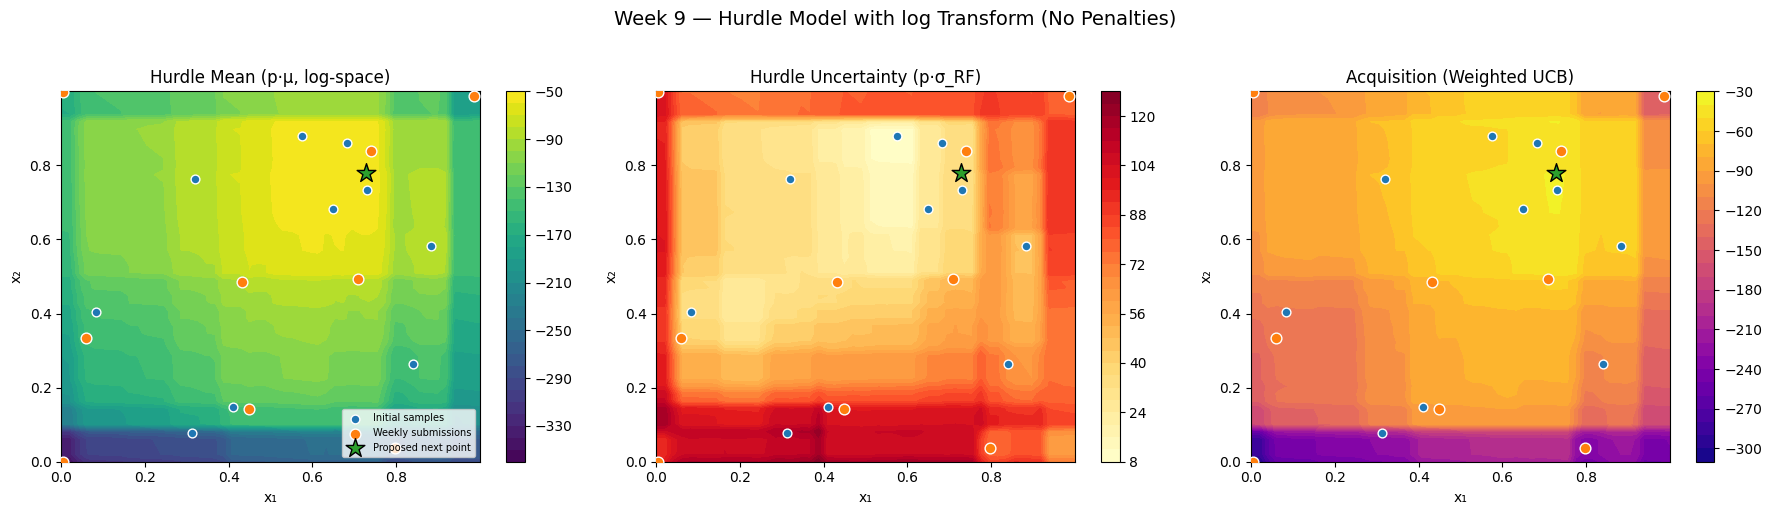

In [10]:
# --- 3-Panel Contour Plot with Three-Colour Scheme ---
x1_vis = np.linspace(0.0, 0.999999, GRID_RES)
x2_vis = np.linspace(0.0, 0.999999, GRID_RES)
X1_vis, X2_vis = np.meshgrid(x1_vis, x2_vis)
X_grid = np.column_stack([X1_vis.ravel(), X2_vis.ravel()])

p_grid = stage1_clf.predict_proba(X_grid)[:, 1]

if not FALLBACK_MODE:
    tree_preds_grid = np.array([tree.predict(X_grid) for tree in stage2_rf.estimators_])
    mu_log_grid     = tree_preds_grid.mean(axis=0)
    sigma_rf_grid   = tree_preds_grid.std(axis=0)
    # Log-space surfaces for visualisation
    grid_hurdle      = (p_grid * mu_log_grid).reshape(GRID_RES, GRID_RES)
    grid_uncertainty = (p_grid * sigma_rf_grid).reshape(GRID_RES, GRID_RES)
    # Raw weighted UCB (no penalties)
    grid_ucb = (p_grid * mu_log_grid + KAPPA * p_grid * sigma_rf_grid).reshape(GRID_RES, GRID_RES)
else:
    grid_hurdle      = p_grid.reshape(GRID_RES, GRID_RES)
    grid_uncertainty = p_grid.reshape(GRID_RES, GRID_RES)
    grid_ucb         = p_grid.reshape(GRID_RES, GRID_RES)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax_idx, (data, title, cmap) in enumerate([
    (grid_hurdle, 'Hurdle Mean (p·μ, log-space)', 'viridis'),
    (grid_uncertainty, 'Hurdle Uncertainty (p·σ_RF)', 'YlOrRd'),
    (grid_ucb, 'Acquisition (Weighted UCB)', 'plasma'),
]):
    ax = axes[ax_idx]
    c = ax.contourf(X1_vis, X2_vis, data, levels=30, cmap=cmap)

    # Initial samples (blue)
    ax.scatter(X_initial[:, 0], X_initial[:, 1], c='tab:blue', s=40,
               edgecolors='white', zorder=5,
               label='Initial samples' if ax_idx == 0 else None)

    # Weekly submissions (orange)
    ax.scatter(X_submissions[:, 0], X_submissions[:, 1], c='tab:orange', s=60,
               edgecolors='white', zorder=5,
               label='Weekly submissions' if ax_idx == 0 else None)

    # Proposed next point (green star)
    ax.scatter(next_x[0], next_x[1], c='tab:green', marker='*', s=200,
               edgecolors='black', zorder=6,
               label='Proposed next point' if ax_idx == 0 else None)

    ax.set_xlabel('x₁'); ax.set_ylabel('x₂')
    ax.set_title(title)
    if ax_idx == 0:
        ax.legend(loc='lower right', fontsize=7)
    plt.colorbar(c, ax=ax)

plt.suptitle('Week 9 — Hurdle Model with log Transform (No Penalties)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

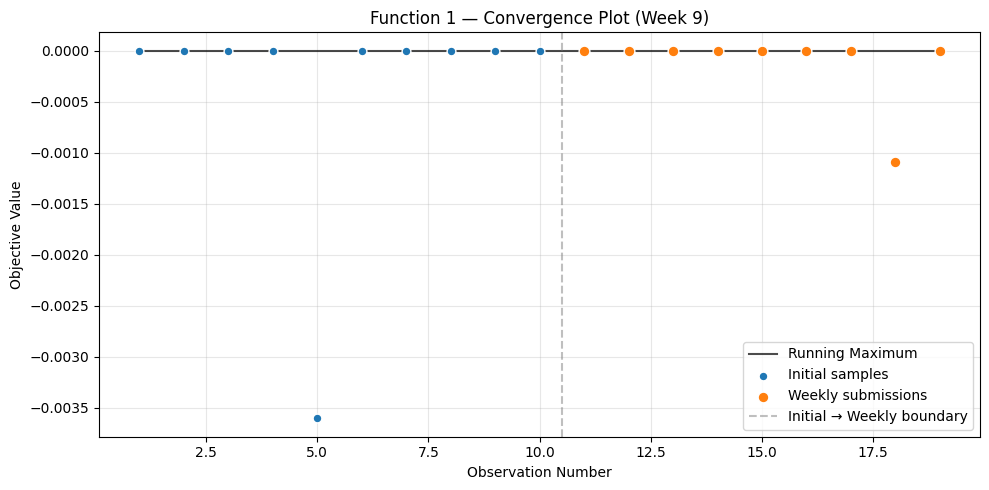

Best observed value: 7.710875e-16  (observation 3)
Best location: (0.731024, 0.733000)
Best after initial:     7.710875e-16
Best after submissions: 7.710875e-16
Submissions improved best: No — initial best retained


In [11]:
# --- Convergence Plot with Two-Colour Scheme ---
running_max = np.maximum.accumulate(y)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(y) + 1), running_max, 'k-', linewidth=1.5, alpha=0.7, label='Running Maximum')

# Individual observations with two-colour scheme
plt.scatter(range(1, N_INITIAL + 1), y[:N_INITIAL],
            c='tab:blue', s=40, edgecolors='white', zorder=5, label='Initial samples')
plt.scatter(range(N_INITIAL + 1, N_TOTAL + 1), y[N_INITIAL:],
            c='tab:orange', s=60, edgecolors='white', zorder=5, label='Weekly submissions')

plt.axvline(x=N_INITIAL + 0.5, color='gray', linestyle='--', alpha=0.5, label='Initial → Weekly boundary')
plt.xlabel('Observation Number')
plt.ylabel('Objective Value')
plt.title('Function 1 — Convergence Plot (Week 9)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best observed value: {y.max():.6e}  (observation {y.argmax() + 1})")
print(f"Best location: ({X[y.argmax(), 0]:.6f}, {X[y.argmax(), 1]:.6f})")
best_initial = y[:N_INITIAL].max()
best_final = y.max()
print(f"Best after initial:     {best_initial:.6e}")
print(f"Best after submissions: {best_final:.6e}")
improved = best_final > best_initial
print(f"Submissions improved best: {'Yes ✓' if improved else 'No — initial best retained'}")

---

## 5 · Performance Evaluation

### Cell 10: Convergence Metrics

Quantitative assessment of optimisation progress. F1's zero-inflated landscape means the best initial value may be ≈ 0; the stalling formula handles this with a zero-guard.

In [12]:
# ── Convergence Metrics ────────────────────────────────────────────────────────
best_initial = y[:N_INITIAL].max()

# Best-value trajectory: running max after each submission
best_trajectory = np.array([y[:N_INITIAL + k + 1].max() for k in range(N_SUBMISSIONS)])

# Per-submission improvement delta
per_submission_delta = np.diff(np.concatenate([[best_initial], best_trajectory]))
new_best_flags = per_submission_delta > 0

# Consecutive no-improvement (tail-only: count backwards from most recent)
tail_no_improve = 0
for flag in reversed(new_best_flags):
    if not flag:
        tail_no_improve += 1
    else:
        break
consecutive_no_improvement = tail_no_improve

# Relative improvement (with zero-guard for F1's zero-inflated outputs)
best_final = y.max()
improvement = best_final - best_initial

if abs(best_initial) < 1e-10:
    relative_improvement = 0.0 if improvement < 1e-10 else 1.0
else:
    relative_improvement = improvement / abs(best_initial)

# Stalling flag
stalling_flag = (consecutive_no_improvement >= STALLING_CONSECUTIVE_THRESHOLD or
                 relative_improvement < STALLING_RELATIVE_THRESHOLD)

# ── Summary Table ─────────────────────────────────────────────────────────────
print("=" * 60)
print("CONVERGENCE METRICS — Function 1, Week 9")
print("=" * 60)
print(f"  Best after initial samples: {best_initial:.6e}")
print(f"  Best after all submissions: {best_final:.6e}")
print(f"  Absolute improvement:       {improvement:.6e}")
print(f"  Relative improvement:       {relative_improvement:.4f} ({relative_improvement*100:.1f}%)")
print(f"  Submissions finding new best: {new_best_flags.sum()} / {N_SUBMISSIONS}")
print(f"  Trailing no-improvement streak: {consecutive_no_improvement}")
print(f"  Stalling flag: {'⚠ YES — STALLING' if stalling_flag else '✓ NO — healthy progress'}")
print()

# Per-submission detail
print(f"{'Sub':>4}  {'Best After':>14}  {'Delta':>12}  {'New Best?':>10}")
print("-" * 46)
for k in range(N_SUBMISSIONS):
    marker = "✓" if new_best_flags[k] else "—"
    print(f"{k+1:>4}  {best_trajectory[k]:>14.6e}  {per_submission_delta[k]:>12.6e}  {marker:>10}")

CONVERGENCE METRICS — Function 1, Week 9
  Best after initial samples: 7.710875e-16
  Best after all submissions: 7.710875e-16
  Absolute improvement:       0.000000e+00
  Relative improvement:       0.0000 (0.0%)
  Submissions finding new best: 0 / 9
  Trailing no-improvement streak: 9
  Stalling flag: ⚠ YES — STALLING

 Sub      Best After         Delta   New Best?
----------------------------------------------
   1    7.710875e-16  0.000000e+00           —
   2    7.710875e-16  0.000000e+00           —
   3    7.710875e-16  0.000000e+00           —
   4    7.710875e-16  0.000000e+00           —
   5    7.710875e-16  0.000000e+00           —
   6    7.710875e-16  0.000000e+00           —
   7    7.710875e-16  0.000000e+00           —
   8    7.710875e-16  0.000000e+00           —
   9    7.710875e-16  0.000000e+00           —


### Cell 11: Exploration Spread

Pairwise Euclidean distances between the 9 weekly submission points. For 2D inputs in [0,1]², uniform random points have mean pairwise distance ~0.52. Values significantly below this indicate clustering.

EXPLORATION SPREAD — Function 1, Week 9
  Number of submissions:        9
  Mean pairwise distance:       0.7069  (uniform 2D ≈ 0.52)
  Max nearest-neighbour dist:   0.6679
  Min nearest-neighbour dist:   0.2764  (tightest cluster)
  Clustering detected:          ✓ No


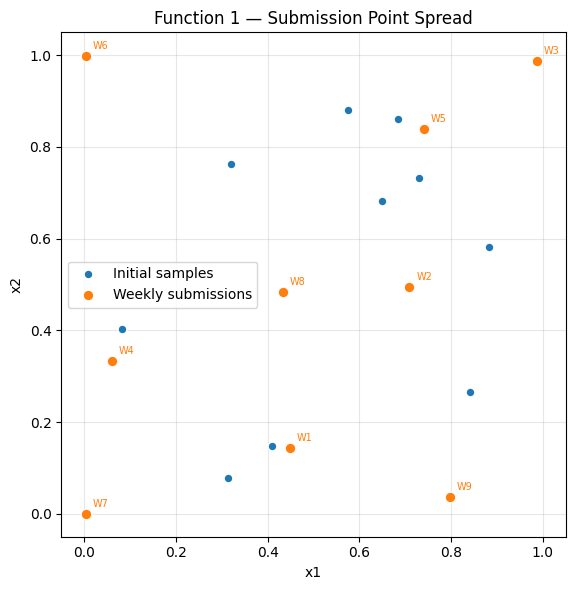

In [13]:
# ── Exploration Spread Metrics ─────────────────────────────────────────────────
dists = pdist(X_submissions)
mean_pairwise = dists.mean()

dist_matrix = squareform(dists)
np.fill_diagonal(dist_matrix, np.inf)
nn_dists = dist_matrix.min(axis=1)
max_nn_dist = nn_dists.max()
min_nn_dist = nn_dists.min()

print("=" * 60)
print("EXPLORATION SPREAD — Function 1, Week 9")
print("=" * 60)
print(f"  Number of submissions:        {N_SUBMISSIONS}")
print(f"  Mean pairwise distance:       {mean_pairwise:.4f}  (uniform 2D ≈ 0.52)")
print(f"  Max nearest-neighbour dist:   {max_nn_dist:.4f}")
print(f"  Min nearest-neighbour dist:   {min_nn_dist:.4f}  (tightest cluster)")

clustered = mean_pairwise < 0.52 * 0.7  # 30% below uniform expectation
print(f"  Clustering detected:          {'⚠ YES' if clustered else '✓ No'}")

# Scatter plot of submission points (2D only)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(X_initial[:, 0], X_initial[:, 1], c='tab:blue', s=40,
           edgecolors='white', zorder=5, label='Initial samples')
ax.scatter(X_submissions[:, 0], X_submissions[:, 1], c='tab:orange', s=60,
           edgecolors='white', zorder=5, label='Weekly submissions')

# Annotate submission order
for k in range(N_SUBMISSIONS):
    ax.annotate(f'W{k+1}', (X_submissions[k, 0], X_submissions[k, 1]),
                textcoords="offset points", xytext=(5, 5), fontsize=7, color='tab:orange')

ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Function 1 — Submission Point Spread')
ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

### Cell 12: LOO Surrogate Error — Hurdle Model

Leave-one-out cross-validation over the 9 weekly submission points. For each fold, retrain both stages of the hurdle model. If removing a point drops `n_positive < 3`, use fallback prediction = 0.

**Note**: With only 9 folds, these metrics have limited statistical power but provide a useful diagnostic.

In [14]:
# ── Leave-One-Out CV (9 folds over submissions) — Hurdle Model ────────────────
loo_predictions = []
loo_actuals = []
loo_errors = []

print(f"{'Fold':>5}  {'Held-Out Idx':>13}  {'Actual':>12}  {'Predicted':>12}  {'Error':>12}  {'Note':>10}")
print("-" * 70)

for fold in range(N_SUBMISSIONS):
    held_out_idx = N_INITIAL + fold

    # Build LOO training set
    mask = np.ones(N_TOTAL, dtype=bool)
    mask[held_out_idx] = False
    X_loo = X[mask]
    y_loo = y[mask]

    # Derive binary labels for LOO set
    y_loo_binary = y_loo > 0
    n_pos_loo = int(y_loo_binary.sum())

    note = ""
    if n_pos_loo < MIN_POSITIVE:
        # Fallback: predict 0
        pred = 0.0
        note = "fallback"
    else:
        # Stage 1: Classifier
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            base_clf = LogisticRegression(C=C_STAGE1, class_weight='balanced',
                                          max_iter=1000, random_state=42)
            clf_loo = CalibratedClassifierCV(base_clf, method='sigmoid', cv=min(3, n_pos_loo))
            clf_loo.fit(X_loo, y_loo_binary)

        # Stage 2: RF on positive subset
        X_pos_loo = X_loo[y_loo_binary]
        y_pos_loo = y_loo[y_loo_binary]
        y_pos_log_loo = np.log(y_pos_loo)

        rf_loo = RandomForestRegressor(n_estimators=N_ESTIMATORS, max_depth=MAX_DEPTH,
                                        random_state=42)
        rf_loo.fit(X_pos_loo, y_pos_log_loo)

        # Predict held-out point
        x_held = X[held_out_idx:held_out_idx+1]
        p_held = clf_loo.predict_proba(x_held)[:, 1][0]
        mu_log_held = rf_loo.predict(x_held)[0]
        pred = p_held * np.exp(mu_log_held)

    actual = y[held_out_idx]
    error = abs(pred - actual)

    loo_predictions.append(pred)
    loo_actuals.append(actual)
    loo_errors.append(error)

    print(f"{fold+1:>5}  {held_out_idx:>13}  {actual:>12.6e}  {pred:>12.6e}  {error:>12.6e}  {note:>10}")

# Summary statistics
loo_predictions = np.array(loo_predictions)
loo_actuals = np.array(loo_actuals)
loo_errors = np.array(loo_errors)

loo_mae = loo_errors.mean()
loo_rmse = np.sqrt((loo_errors**2).mean())

print(f"\n{'='*70}")
print(f"LOO SURROGATE ERROR — Function 1 (Hurdle Model)")
print(f"{'='*70}")
print(f"  MAE:  {loo_mae:.6e}")
print(f"  RMSE: {loo_rmse:.6e}")
print(f"  Max error:  {loo_errors.max():.6e} (fold {loo_errors.argmax()+1})")
print(f"  Min error:  {loo_errors.min():.6e} (fold {loo_errors.argmin()+1})")
print(f"  Fallback folds: {sum(1 for p in loo_predictions if p == 0.0)}")
print(f"  Note: 9-fold LOO has limited statistical power")

 Fold   Held-Out Idx        Actual     Predicted         Error        Note
----------------------------------------------------------------------
    1             10  2.314081e-56  4.479183e-148  2.314081e-56            
    2             11  -1.159884e-17  1.111883e-45  1.159884e-17            
    3             12  4.977703e-180  1.700730e-52  1.700730e-52            
    4             13  2.842720e-97  1.037117e-85  1.037117e-85            
    5             14  1.018730e-40  7.414727e-41  2.772574e-41            
    6             15  0.000000e+00  7.290821e-115  7.290821e-115            
    7             16  1.874280e-245  2.202847e-121  2.202847e-121            
    8             17  -1.091232e-03  4.141393e-62  1.091232e-03            
    9             18  6.936278e-202  1.354370e-150  1.354370e-150            

LOO SURROGATE ERROR — Function 1 (Hurdle Model)
  MAE:  1.212480e-04
  RMSE: 3.637439e-04
  Max error:  1.091232e-03 (fold 8)
  Min error:  1.354370e-150 (fold 9)
  F

### Cell 13: Interpretation & Strategy Recommendations

**Convergence Assessment**:  
F1 has historically shown zero or minimal improvement — the radiation source remains undetected. The stalling flag above reflects this persistent lack of progress. However, the log transform provides the surrogate meaningful signal, justifying exploitation (KAPPA=0.5).

**Exploration Spread**:  
For 2D inputs in [0,1]², uniform random points give mean pairwise distance ≈ 0.52. With KAPPA=0.5 (exploitation-focused), submissions may cluster near predicted optima — this is intentional given only 4 budget submissions remain.

**LOO Surrogate Accuracy**:  
The hurdle model's LOO MAE/RMSE indicate predictive quality. For F1's zero-inflated outputs, many folds may use fallback (prediction = 0), making the LOO primarily diagnostic of the rare positive-output regime.

**If stalling, consider these strategy changes for Week 10**:
1. **Switch to SingleTaskGP** — if positive outputs now exist, a GP surrogate may model the landscape better than the hurdle model
2. **Further reduce KAPPA to 0.1** — near-greedy exploitation if surrogate accuracy justifies it
3. **Re-introduce local penalization** — if submissions are clustering too tightly, a Gaussian mask (e.g., radius=0.15) could enforce diversity
4. **Use LHS candidates instead of random** — Latin Hypercube Sampling provides better space coverage than uniform random for acquisition candidate generation

**If not stalling**: Continue with the current Hurdle Model + exploitation-focused Weighted UCB strategy. The log transform gives the surrogate meaningful signal to exploit.

## Analysis of Function 1 — Why log(y) Instead of log1p(y), Why Remove Penalties, and Why Exploit

### Why log1p fails for F1

F1's positive outputs range from $1e-245$ to $1e-16$ — a span of ~229 orders of magnitude. The `log1p` transform used in Week 8 was ineffective at this scale.

- $\log1p(y)$: For tiny values like $1e-79$, $\log1p(1e-79) \approx 1e-79$. The Taylor expansion $\log(1+\varepsilon) \approx \varepsilon$ means $\log1p$ does nothing for values already near zero.
- BoTorch standardization: Subtracting the mean and dividing by std still leaves all values clustered at $\sim 0$ because the range is so compressed in absolute terms.

### The better scale: log(y) — applied in this notebook

Prequential evaluation showed this works — $\log(|y|)$ dropped NLP from $\sim 430$ to $\sim 5.2$ and coverage from 0% to 83%. The reason is straightforward:

| Raw value | log1p(y) | log(y) |
|-----------|----------|--------|
| 7.71e-16 | ≈ 7.71e-16 | -34.8 |
| 1.03e-46 | ≈ 1.03e-46 | -106.2 |
| 1.87e-245 | ≈ 1.87e-245 | -564.5 |

With $\log(y)$, the outputs become interpretable numbers in roughly $[-565, -35]$ — a range the surrogate and acquisition function can actually work with.

### Why remove penalties

With only 19 points in [0,1]², coverage is sparse. Local penalization (Gaussian mask with PENALTY_RADIUS=0.15) may over-restrict the search. Interior penalty (sinusoidal with STEEPNESS=0.1, FLOOR=0.01) suppressed boundary candidates that could contain viable optima. Removing both:
- Lets the data and acquisition term drive candidate selection naturally
- Simplifies the acquisition function (constitution Principle I — Simplicity)
- Allows full [0,1]² domain exploration including boundaries

### Why KAPPA=0.5 (exploitation-focused)

The log transform gives the surrogate meaningful signal (R² ≈ 0.90 on log-scale targets). With the surrogate now able to differentiate observations, shifting to exploitation makes sense:
- **Only 4 budget submissions remain** — insufficient budget for broad exploration
- **Surrogate has meaningful signal** — the log transform produces a ~530-unit range, giving the RF regressor real gradients to learn from
- **KAPPA=0.5** balances slight exploration pressure with strong exploitation, sampling near the surrogate's predicted best regions

### Changes applied in this notebook (vs Week 8)

**Stage 2 training**:
```python
# Week 8: y_pos_log = np.log1p(y_pos)
# Week 9: 
y_pos_log = np.log(y_pos)
```

**Acquisition function**:
```python
# Week 8: acq_final = acq_raw * penalty * interior_weight
# Week 9:
acq_final = p_cand * mu_cand + KAPPA * p_cand * sigma_rf_cand  # raw UCB, no penalties
```

**KAPPA change**:
```python
# Previous: KAPPA = 3.0  (exploration-focused)
# Now:      KAPPA = 0.5  (exploitation-focused)
```

**Removed hyperparameters**: PENALTY_RADIUS, STEEPNESS, FLOOR